# Car Dimensions: A Look Through Time

Have cars of the same model grown larger over the years, or does the change in size depend on the specific model?

To explore this question, we have a dataset in the file `car-dimensions.csv`, which presents the `length`, `width`, and `height` (all in millimeters) for 53 car models. This dataset includes measurements from the earliest generation of each model that we could find, as well as data from the latest model. 

By analyzing this information, we can uncover trends and patterns in the evolution of car dimensions over time.

In [1]:
# FOR GOOGLE COLAB ONLY.
# Uncomment and run the code below. A dialog will appear to upload files.
# Upload 'car-dimensions.csv'.

# from google.colab import files
# uploaded = files.upload()

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('car-dimensions.csv')
df.head(4)

,brand_model,length,width,height,year,generation
0,Audi A4,4520,1733,1415,1994,first
1,Audi A4,4762,1847,1427,2015,latest
2,BMW 3 Series,4355,1610,1380,1975,first
3,BMW 3 Series,4829,1827,1442,2018,latest


In [2]:
first_generation = df.query('generation == "first"')
first_generation.head(2)

,brand_model,length,width,height,year,generation
0,Audi A4,4520,1733,1415,1994,first
2,BMW 3 Series,4355,1610,1380,1975,first


In [3]:
latest_generation = df.query('generation == "latest"')
latest_generation.head(2)

,brand_model,length,width,height,year,generation
1,Audi A4,4762,1847,1427,2015,latest
3,BMW 3 Series,4829,1827,1442,2018,latest


In [5]:
# helper function, change gap, vertical alignment, horizontal alignment, placement of gap...
def add_labels(df, x_col, y_col, label_col):
	for i, row in df.iterrows():
		x = row[x_col]
		y = row[y_col]
		gap = "  "
		label = gap + row[label_col]
		plt.text(x, y, label, va='center', ha='left')

### Project Ideas
- Create paired scatter plots of car `width`, `length`, or `height`.

- Follow the Pro Tips.

- Add labels to datapoints to tell a story.

- Create new variables such as:
	- `car footprint = (length * width)`
	- `percent change = (latest - first) / first`
	
- Create horizontal bar plots showing which car models have changed the least or most for a variable of your choice.

Below is a preliminary paired scatter plot of car `length` to get you started. 

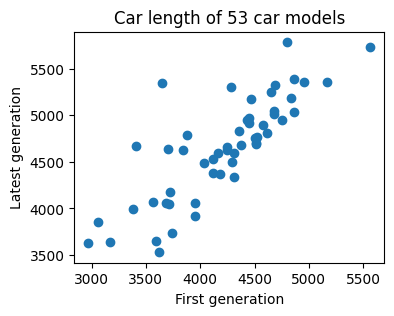

In [6]:
plt.figure(figsize=(4, 3))  
plt.scatter(first_generation['length'], latest_generation['length'])
plt.xlabel('First generation')
plt.ylabel('Latest generation')
plt.title('Car length of 53 car models')
plt.show()

In [18]:
first_len = first_generation.set_index('brand_model')['length']
latest_len = latest_generation.set_index('brand_model')['length']

per_change = ((latest_len - first_len)/first_len)*100
per_change.head()

brand_model
Audi A4                 5.353982
BMW 3 Series           10.884041
BMW 7 Series           10.925926
Chevrolet Corvette      8.966816
Chevrolet Silverado     3.640589
Name: length, dtype: float64

In [28]:
# Calculate car footprint (length * width) in square meters
df['footprint_m2'] = (df['length'] * df['width']) / 1_000_000

# Pivot data to get side-by-side comparison per car model
pivot_df = df.pivot(index='brand_model', columns='generation')
pivot_df.head()

length        width        height         year         \
generation           first latest first latest  first latest first latest   
brand_model                                                                 
Audi A4               4520   4762  1733   1847   1415   1427  1994   2015   
BMW 3 Series          4355   4829  1610   1827   1380   1442  1975   2018   
BMW 7 Series          4860   5391  1800   1950   1430   1544  1986   2022   
Chevrolet Corvette    4249   4630  1773   1933   1308   1234  1953   2020   
Chevrolet Silverado   5164   5352  1994   2062   1880   1930  1999   2019   

                    car_footprint           footprint_m2             
generation                  first    latest        first     latest  
brand_model                                                          
Audi A4                   7833160   8795414     7.833160   8.795414  
BMW 3 Series              7011550   8822583     7.011550   8.822583  
BMW 7 Series              8748000  10512450     8.748000  10.512450  
Chevrolet Corvette        7533477   8949790     7.533477   8.949790  
Chevrolet Silverado      10297016  11035824    10.297016  11.035824

In [20]:
# Calculate percent change for each variable
for var in ['length', 'width', 'height', 'footprint_m2']:
    pivot_df[(f'{var}_pct_change', '')] = (
        (pivot_df[var]['latest'] - pivot_df[var]['first']) / pivot_df[var]['first']
    ) * 100

In [22]:
# Clean up DataFrame structure
pct_df = pd.DataFrame({
    'length_pct': ((pivot_df['length']['latest'] - pivot_df['length']['first']) / pivot_df['length']['first']) * 100,
    'width_pct': ((pivot_df['width']['latest'] - pivot_df['width']['first']) / pivot_df['width']['first']) * 100,
    'height_pct': ((pivot_df['height']['latest'] - pivot_df['height']['first']) / pivot_df['height']['first']) * 100,
    'footprint_pct': ((pivot_df['footprint_m2']['latest'] - pivot_df['footprint_m2']['first']) / pivot_df['footprint_m2']['first']) * 100
})
pct_df.head()

,length_pct,width_pct,height_pct,footprint_pct
brand_model,,,,
Audi A4,5.353982,6.578188,0.848057,12.284365
BMW 3 Series,10.884041,13.478261,4.492754,25.829282
BMW 7 Series,10.925926,8.333333,7.972028,20.169753
Chevrolet Corvette,8.966816,9.024253,-5.657492,18.800257
Chevrolet Silverado,3.640589,3.410231,2.659574,7.174972


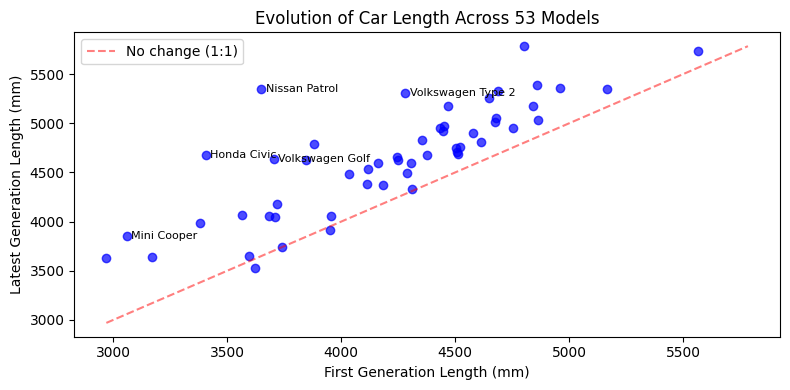

In [26]:
plt.figure(figsize=(8, 4))
# Reference line where length has not changed (y = x)
min_val = min(first_generation['length'].min(), latest_generation['length'].min())
max_val = max(first_generation['length'].max(), latest_generation['length'].max())

plt.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.5, label='No change (1:1)')
# Scatter plot
plt.scatter(first_generation['length'], latest_generation['length'], alpha=0.7, color='b')

# Label models with largest or smallest changes
top_growers = pct_df['length_pct'].nlargest(5).index

for idx, row in first_generation.iterrows():
    model = row['brand_model']
    if model in top_growers:
        x = row['length']
        y = latest_generation.loc[latest_generation['brand_model'] == model, 'length'].values[0]
        plt.text(x + 20, y, model, fontsize=8, va='center')
        
plt.xlabel('First Generation Length (mm)')
plt.ylabel('Latest Generation Length (mm)')
plt.title('Evolution of Car Length Across 53 Models')
plt.legend()
plt.tight_layout()
plt.show()

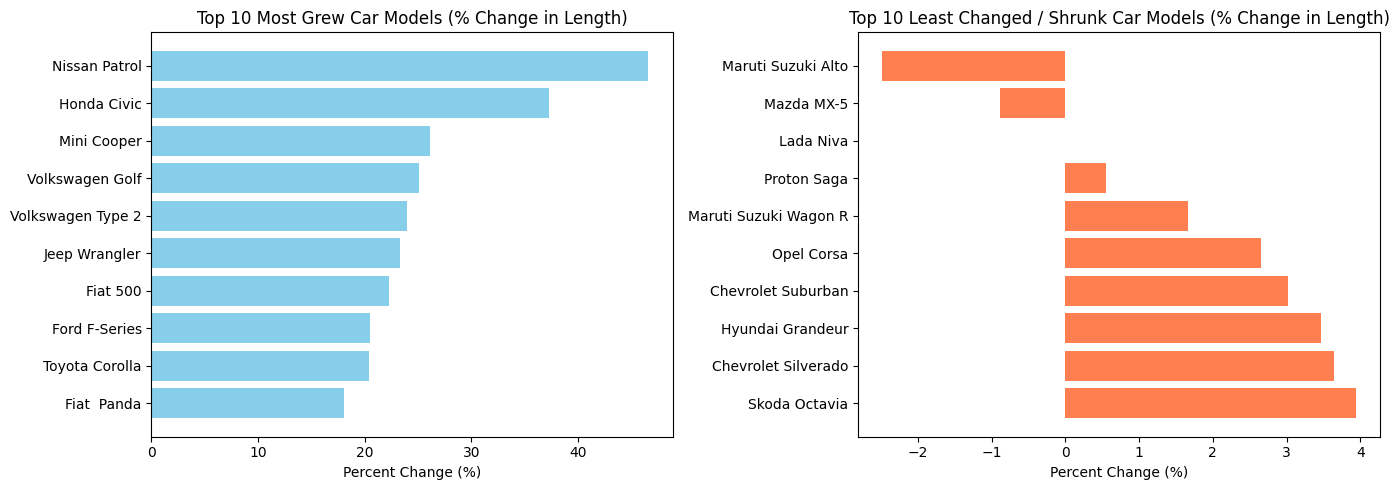

In [27]:
# Top 10 most changed and least changed models
most_changed = pct_df['length_pct'].nlargest(10).sort_values()
least_changed = pct_df['length_pct'].nsmallest(10).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Most Changed
axes[0].barh(most_changed.index, most_changed.values, color='skyblue')
axes[0].set_title('Top 10 Most Grew Car Models (% Change in Length)')
axes[0].set_xlabel('Percent Change (%)')

# Plot Least Changed
axes[1].barh(least_changed.index, least_changed.values, color='coral')
axes[1].set_title('Top 10 Least Changed / Shrunk Car Models (% Change in Length)')
axes[1].set_xlabel('Percent Change (%)')

plt.tight_layout()
plt.show()